# Notebook 05 — Publication-Quality Figures

This notebook produces all the final figures for the paper. No computation is done here, pre-computed results from the earlier notebooks are read and turned into nice-looking plots. All figures are saved as high-resolution PNGs to the `figures/` directory.

The notebook is organized by paper section:
1. **Earnings proximity analysis**: how close are the insider trades to earnings calls? Do trades near earnings have different CARs?
2. **H1 & H2: CAR time series and distributions**: the main event study results
3. **H3: LLM validation**: comparison heatmaps showing whether traditional and LLM CARs differ
4. **Significance summary**: G-Rank test p-value heatmaps

**Inputs:**
- All CSV outputs from notebooks 01–04
- `earnings_dates_cache.csv`: cached earnings call dates from Yahoo Finance

**Outputs:**
- `figures/*.png`: all publication figures
- `earnings_proximity_results.csv`: earnings proximity analysis results

In [2]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.3)
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

DATA = pathlib.Path(".")
FIG = pathlib.Path("./figures")
FIG.mkdir(exist_ok=True)

EVENT_COLORS = {
    "P - Purchase": "#009E73",
    "S - Sale": "#0072B2",
    "S - Sale+OE": "#E69F00",
}
EVENT_ORDER = [
    "P - Purchase",
    "S - Sale", 
    "S - Sale+OE"
    ]

CAR_WINDOWS = ["CAR_pre20_pre1", "CAR_0_1", "CAR_0_5", "CAR_0_10", "CAR_0_20", "CAR_pre20_20"]
CAR_LABELS = ["[-20,-1]", "[0,+1]", "[0,+5]", "[0,+10]", "[0,+20]", "[-20,+20]"]
CAR_LABEL_MAP = dict(zip(CAR_WINDOWS, CAR_LABELS))


In [3]:
meta = pd.read_csv(DATA / "event_study_metadata.csv", parse_dates=["event_date"])
ar = pd.read_csv(DATA / "event_study_abnormal_returns.csv", parse_dates=["date", "event_date"])
cs = pd.read_csv(DATA / "cross_sectional_results.csv")
car_all = pd.read_csv(DATA / "cumulative_abnormal_returns_exclude.csv", parse_dates=["event_date"])
llm_ar = pd.read_csv(DATA / "llm_abnormal_returns.csv")

# split CARs by source and restrict to Purchase + Sale only
trad_car = car_all[(car_all["source"] == "traditional") & (car_all["event_type"].isin(EVENT_ORDER))].copy()
llm_car  = car_all[(car_all["source"] == "llm")         & (car_all["event_type"].isin(EVENT_ORDER))].copy()

print(f"Metadata events: {len(meta)}")
print(f"Traditional CARs: {len(trad_car)}, LLM CARs: {len(llm_car)}")
print(f"Daily ARs: {len(ar):,}")
print(f"LLM daily ARs: {len(llm_ar):,}")

Metadata events: 492
Traditional CARs: 420, LLM CARs: 420
Daily ARs: 19,474
LLM daily ARs: 19,474


## Earnings Proximity Analysis

Before looking at the main results, it is checked how insider trades relate to earnings announcements. This is relevant because trades near earnings calls might be driven by different information than trades at other times, and earnings announcements themselves generate abnormal returns that could confound the analysis.

The distance (in trading days) from each insider trade to the nearest earnings call is computed, trades are classified as "before" or "after" earnings, and it is examined whether the earnings surprise direction (positive/negative) correlates with the trade type. CARs for events near vs far from earnings calls are also compared.

In [4]:
import time
import yfinance as yf
from pathlib import Path

PROXIMITY_BUCKETS = [5, 10, 20]

CAR_COLUMNS = [
    "CAR_pre20_pre1",
    "CAR_0_1",
    "CAR_0_5",
    "CAR_0_10",
    "CAR_0_20",
]

def load_market_calendar(path="market_returns.csv"):
    mkt = pd.read_csv(path, parse_dates=["date"])
    return np.sort(mkt["date"].dropna().unique())

def trading_day_distance(date_a, date_b, trading_cal):
    idx_a = np.searchsorted(trading_cal, np.datetime64(date_a), side="right") - 1
    idx_b = np.searchsorted(trading_cal, np.datetime64(date_b), side="right") - 1
    idx_a = max(0, min(idx_a, len(trading_cal) - 1))
    idx_b = max(0, min(idx_b, len(trading_cal) - 1))
    return int(idx_b - idx_a)

In [5]:
def download_earnings_dates(tickers, margin_months=6):
    all_rows = []
    for i, ticker in enumerate(tickers):
        print(f"  [{i+1}/{len(tickers)}] Fetching earnings dates for {ticker}...", end=" ")
        try:
            tk = yf.Ticker(ticker)
            edf = tk.get_earnings_dates(limit=20)
            if edf is None or edf.empty:
                print("no data")
                continue
            edf = edf.reset_index()
            edf = edf.rename(columns={
                "Earnings Date": "earnings_date",
                "EPS Estimate": "eps_estimate",
                "Reported EPS": "reported_eps",
                "Surprise(%)": "surprise_pct",
            })
            edf["ticker"] = ticker
            past = edf[edf["reported_eps"].notna()].copy()
            print(f"{len(past)} past earnings dates")
            all_rows.append(past[["ticker", "earnings_date", "eps_estimate",
                                   "reported_eps", "surprise_pct"]])
        except Exception as e:
            print(f"error: {e}")
        if (i + 1) % 10 == 0:
            time.sleep(1)
    if not all_rows:
        raise RuntimeError("Failed to download any earnings dates")
    earnings_df = pd.concat(all_rows, ignore_index=True)
    earnings_df["earnings_date"] = pd.to_datetime(
        earnings_df["earnings_date"]
    ).dt.tz_localize(None)
    print(f"\nTotal earnings records: {len(earnings_df)}")
    return earnings_df


def compute_proximity(events_df, earnings_df, trading_cal):
    results = []
    for _, event in events_df.iterrows():
        ticker = event["ticker"]
        edate = event["event_date"]
        tk_earnings = earnings_df[earnings_df["ticker"] == ticker].copy()
        if tk_earnings.empty:
            results.append({
                "nearest_earnings_date": pd.NaT,
                "days_to_earnings": np.nan,
                "abs_days_to_earnings": np.nan,
                "earnings_surprise_pct": np.nan,
                "pre_earnings": False,
            })
            continue
        tk_earnings["cal_dist"] = (tk_earnings["earnings_date"] - edate).abs()
        tk_earnings = tk_earnings.sort_values("cal_dist")
        candidates = tk_earnings.head(4)
        best_dist = None
        best_row = None
        for _, earn_row in candidates.iterrows():
            dist = trading_day_distance(edate, earn_row["earnings_date"], trading_cal)
            if best_dist is None or abs(dist) < abs(best_dist):
                best_dist = dist
                best_row = earn_row
        results.append({
            "nearest_earnings_date": best_row["earnings_date"],
            "days_to_earnings": best_dist,
            "abs_days_to_earnings": abs(best_dist),
            "earnings_surprise_pct": best_row["surprise_pct"],
            "pre_earnings": best_dist > 0,
        })
    prox_df = pd.DataFrame(results)
    return pd.concat([events_df.reset_index(drop=True), prox_df], axis=1)

In [6]:
def print_proximity_summary(df):
    valid = df[df["days_to_earnings"].notna()]
    print("EARNINGS PROXIMITY SUMMARY")
    print(f"\nEvents with matched earnings data: {len(valid)} / {len(df)}")
    print(f"\nDistance to nearest earnings call (trading days):")
    print(f"  Mean:   {valid['abs_days_to_earnings'].mean():.1f}")
    print(f"  Median: {valid['abs_days_to_earnings'].median():.1f}")
    print(f"  Min:    {valid['abs_days_to_earnings'].min():.0f}")
    print(f"  Max:    {valid['abs_days_to_earnings'].max():.0f}")
    print(f"\nEvents within N trading days of earnings:")
    for bucket in PROXIMITY_BUCKETS:
        n_within = (valid["abs_days_to_earnings"] <= bucket).sum()
        pct = 100 * n_within / len(valid)
        print(f"  ≤{bucket:2d} days: {n_within:4d} ({pct:.1f}%)")
    n_before = valid["pre_earnings"].sum()
    n_after = len(valid) - n_before
    print(f"\nTiming relative to nearest earnings:")
    print(f"  Before earnings: {n_before} ({100*n_before/len(valid):.1f}%)")
    print(f"  After earnings:  {n_after} ({100*n_after/len(valid):.1f}%)")
    print(f"\n--- By Event Type ---")
    for etype in sorted(valid["event_type"].unique()):
        sub = valid[valid["event_type"] == etype]
        print(f"\n  {etype} (N={len(sub)}):")
        print(f"    Mean abs distance: {sub['abs_days_to_earnings'].mean():.1f} days")
        print(f"    Median abs distance: {sub['abs_days_to_earnings'].median():.1f} days")
        for bucket in PROXIMITY_BUCKETS:
            n_within = (sub["abs_days_to_earnings"] <= bucket).sum()
            print(f"    ≤{bucket:2d} days: {n_within} ({100*n_within/len(sub):.1f}%)")


def print_surprise_analysis(df):
    valid = df[df["earnings_surprise_pct"].notna() & df["days_to_earnings"].notna()]
    if len(valid) == 0:
        print("\nNo earnings surprise data available.")
        return
    print("EARNINGS SURPRISE ANALYSIS")
    pre = valid[(valid["pre_earnings"]) & (valid["abs_days_to_earnings"] <= 20)]
    print(f"\nEvents within 20 trading days BEFORE earnings: {len(pre)}")
    if len(pre) == 0:
        print("  No pre-earnings events to analyze.")
        return
    pre = pre.copy()
    pre["surprise_direction"] = pd.cut(
        pre["earnings_surprise_pct"],
        bins=[-np.inf, -0.01, 0.01, np.inf],
        labels=["Negative", "Neutral", "Positive"],
    )
    print(f"\n--- Event Type x Earnings Surprise (pre-earnings events, <=20 days) ---")
    ct = pd.crosstab(pre["event_type"], pre["surprise_direction"], margins=True)
    print(ct.to_string())
    print(f"\n--- Mean CARs by Surprise Direction (pre-earnings events, <=20 days) ---")
    for car_col in CAR_COLUMNS:
        if car_col not in pre.columns:
            continue
        grouped = pre.groupby("surprise_direction", observed=True)[car_col].agg(["mean", "count"])
        if grouped["count"].sum() > 0:
            print(f"\n  {car_col}:")
            for direction, row in grouped.iterrows():
                if row["count"] > 0:
                    print(f"    {direction}: mean={row['mean']:.6f} (N={int(row['count'])})")
    print(f"\n--- Mean CARs by Surprise Direction x Event Type ---")
    for etype in sorted(pre["event_type"].unique()):
        sub = pre[pre["event_type"] == etype]
        if len(sub) < 2:
            continue
        print(f"\n  {etype}:")
        for car_col in ["CAR_0_1", "CAR_0_5", "CAR_0_10"]:
            if car_col not in sub.columns:
                continue
            grouped = sub.groupby("surprise_direction", observed=True)[car_col].agg(["mean", "count"])
            print(f"    {car_col}:")
            for direction, row in grouped.iterrows():
                if row["count"] > 0:
                    print(f"      {direction}: mean={row['mean']:.6f} (N={int(row['count'])})")


def print_proximity_car_analysis(df):
    valid = df[df["abs_days_to_earnings"].notna()]
    if len(valid) == 0:
        return
    print("CARs BY EARNINGS PROXIMITY")
    for bucket in [10, 20]:
        near = valid[valid["abs_days_to_earnings"] <= bucket]
        far = valid[valid["abs_days_to_earnings"] > bucket]
        print(f"\n--- Near (<={bucket} days, N={len(near)}) vs Far (>{bucket} days, N={len(far)}) ---")
        for car_col in ["CAR_0_1", "CAR_0_5", "CAR_0_10", "CAR_0_20"]:
            if car_col not in valid.columns:
                continue
            near_mean = near[car_col].mean()
            far_mean = far[car_col].mean()
            print(f"  {car_col}: near={near_mean:.6f}, far={far_mean:.6f}, diff={near_mean-far_mean:.6f}")

In [7]:
events_df = meta.copy()
trading_cal = load_market_calendar()

cache_path = Path("earnings_dates_cache.csv")
if cache_path.exists():
    print(f"Loading cached earnings dates from {cache_path}")
    earnings_df = pd.read_csv(cache_path, parse_dates=["earnings_date"])
    print(f"  {len(earnings_df)} records")
else:
    print("Downloading earnings dates from Yahoo Finance...")
    tickers = sorted(events_df["ticker"].unique())
    earnings_df = download_earnings_dates(tickers)
    earnings_df.to_csv(cache_path, index=False)
    print(f"  Cached to {cache_path}")

print("\nComputing earnings proximity...")
result_df = compute_proximity(events_df, earnings_df, trading_cal)

# Merge CARs from traditional model for surprise/proximity CAR analysis
car_cols = [c for c in CAR_COLUMNS if c in trad_car.columns]
if car_cols:
    result_df = result_df.merge(
        trad_car[["ticker", "event_date", "event_type"] + car_cols],
        on=["ticker", "event_date", "event_type"],
        how="left",
    )

print_proximity_summary(result_df)
print_surprise_analysis(result_df)
print_proximity_car_analysis(result_df)

result_df.to_csv("earnings_proximity_results.csv", index=False)
print(f"\nSaved {len(result_df)} rows to earnings_proximity_results.csv")

Loading cached earnings dates from earnings_dates_cache.csv
  689 records

Computing earnings proximity...
EARNINGS PROXIMITY SUMMARY

Events with matched earnings data: 492 / 492

Distance to nearest earnings call (trading days):
  Mean:   13.7
  Median: 13.0
  Min:    0
  Max:    34

Events within N trading days of earnings:
  ≤ 5 days:  110 (22.4%)
  ≤10 days:  207 (42.1%)
  ≤20 days:  376 (76.4%)

Timing relative to nearest earnings:
  Before earnings: 174 (35.4%)
  After earnings:  318 (64.6%)

--- By Event Type ---

  P - Purchase (N=12):
    Mean abs distance: 13.8 days
    Median abs distance: 12.0 days
    ≤ 5 days: 4 (33.3%)
    ≤10 days: 6 (50.0%)
    ≤20 days: 8 (66.7%)

  S - Sale (N=315):
    Mean abs distance: 13.5 days
    Median abs distance: 13.0 days
    ≤ 5 days: 73 (23.2%)
    ≤10 days: 136 (43.2%)
    ≤20 days: 244 (77.5%)

  S - Sale+OE (N=165):
    Mean abs distance: 14.0 days
    Median abs distance: 13.0 days
    ≤ 5 days: 33 (20.0%)
    ≤10 days: 65 (39.4%)
 

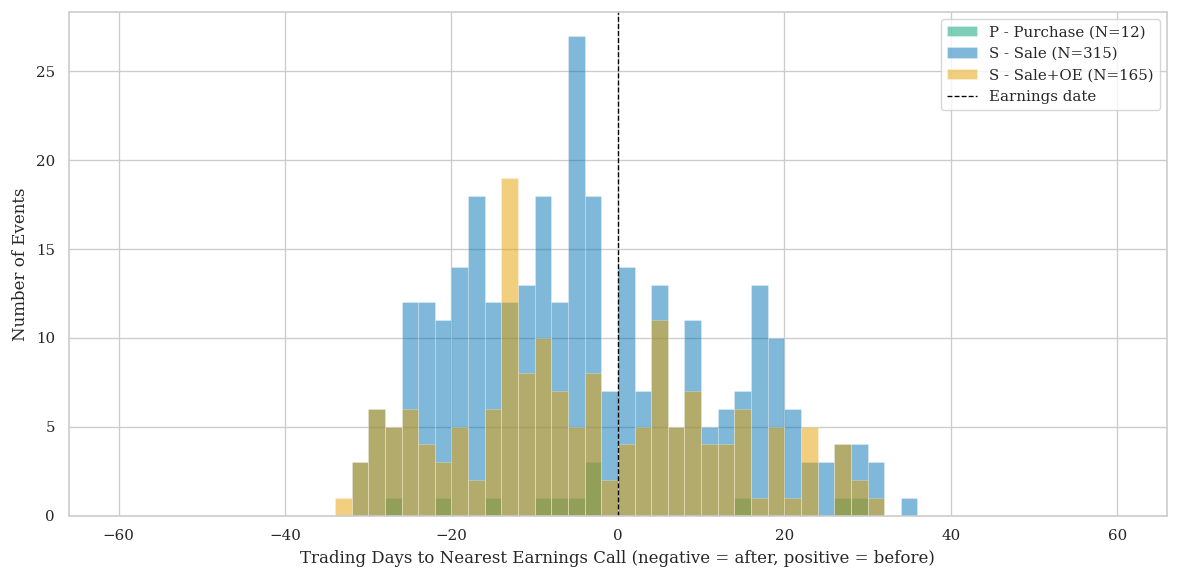

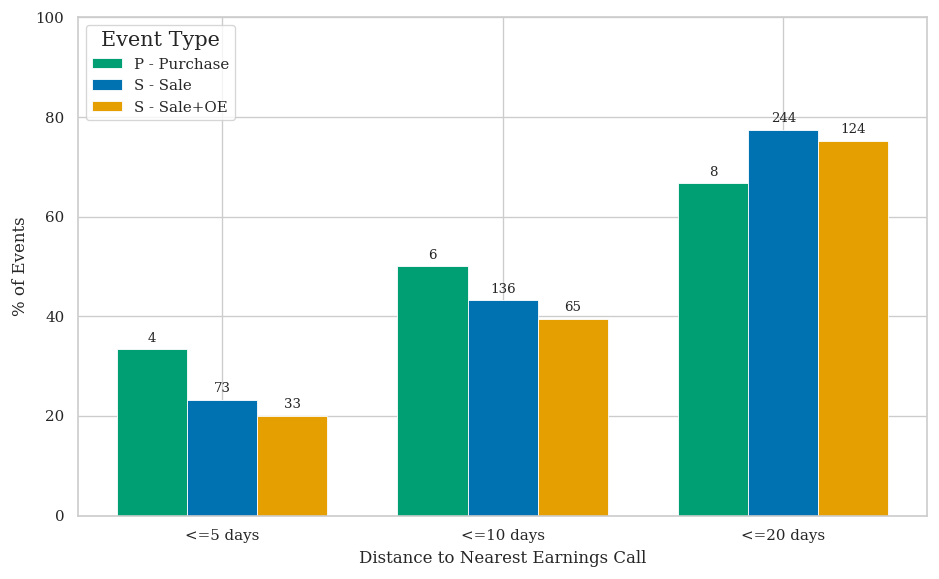

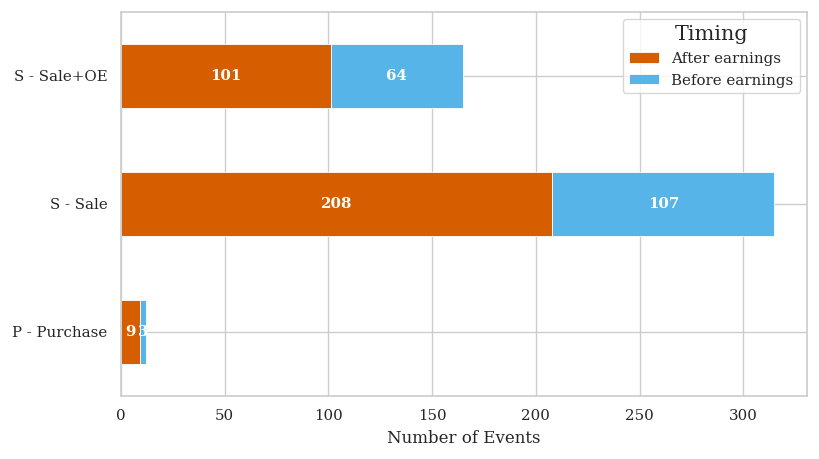

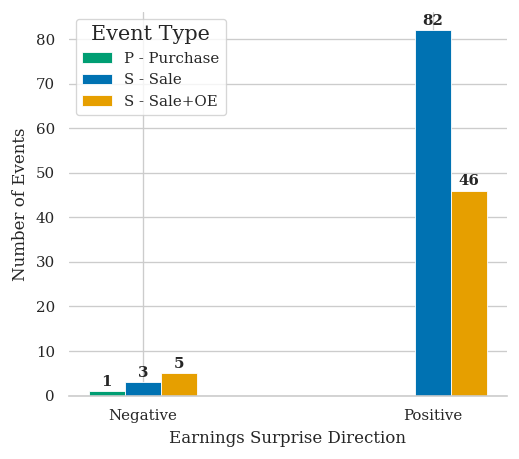

In [8]:
valid = result_df[result_df["days_to_earnings"].notna()].copy()

fig_dir = Path("figures")
fig_dir.mkdir(parents=True, exist_ok=True)

# Histogram: Distance to Nearest Earnings Call by Event Type
fig, ax = plt.subplots(figsize=(10, 5))
for etype in EVENT_ORDER:
    sub = valid[valid["event_type"] == etype]
    ax.hist(
        sub["days_to_earnings"], bins=range(-60, 61, 2),
        alpha=0.5, label=f"{etype} (N={len(sub)})", color=EVENT_COLORS[etype],
        edgecolor="white", linewidth=0.3,
    )
ax.axvline(0, color="black", linewidth=0.8, linestyle="--", label="Earnings date")
ax.set_xlabel("Trading Days to Nearest Earnings Call (negative = after, positive = before)")
ax.set_ylabel("Number of Events")
ax.legend()
plt.tight_layout()
fig.savefig(fig_dir / "01_days_to_earnings_hist_by_event_type.png", dpi=200, bbox_inches="tight")
plt.show()

# Proximity Buckets by Event Type
bucket_data = []
for etype in EVENT_ORDER:
    sub = valid[valid["event_type"] == etype]
    n = len(sub)
    for bucket in PROXIMITY_BUCKETS:
        n_within = (sub["abs_days_to_earnings"] <= bucket).sum()
        bucket_data.append({
            "event_type": etype,
            "bucket": f"<={bucket} days",
            "count": n_within,
            "pct": 100 * n_within / n if n > 0 else 0,
        })

bucket_df = pd.DataFrame(bucket_data)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(PROXIMITY_BUCKETS))
bar_width = 0.25
for i, etype in enumerate(EVENT_ORDER):
    sub = bucket_df[bucket_df["event_type"] == etype]
    bars = ax.bar(
        x + i * bar_width, sub["pct"], bar_width,
        label=etype, color=EVENT_COLORS[etype], edgecolor="white", linewidth=0.5,
    )
    for bar, row in zip(bars, sub.itertuples()):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{int(row.count)}", ha="center", va="bottom", fontsize=8
        )

ax.set_xticks(x + bar_width)
ax.set_xticklabels([f"<={b} days" for b in PROXIMITY_BUCKETS])
ax.set_xlabel("Distance to Nearest Earnings Call")
ax.set_ylabel("% of Events")
ax.legend(title="Event Type")
ax.set_ylim(0, 100)
plt.tight_layout()
fig.savefig(fig_dir / "02_proximity_buckets_by_event_type.png", dpi=200, bbox_inches="tight")
plt.show()

# Before vs After Earnings by Event Type
timing_data = []
for etype in EVENT_ORDER:
    sub = valid[valid["event_type"] == etype]
    n_before = sub["pre_earnings"].sum()
    n_after = len(sub) - n_before
    timing_data.append({"event_type": etype, "timing": "Before earnings", "count": n_before})
    timing_data.append({"event_type": etype, "timing": "After earnings", "count": n_after})

timing_df = pd.DataFrame(timing_data)
timing_pivot = timing_df.pivot(index="event_type", columns="timing", values="count").reindex(EVENT_ORDER)

fig, ax = plt.subplots(figsize=(7, 4))
timing_pivot.plot.barh(
    stacked=True, ax=ax, color=["#D55E00", "#56B4E9"], edgecolor="white", linewidth=0.5
)
for container in ax.containers:
    ax.bar_label(container, label_type="center", fontsize=9, color="white", fontweight="bold")
ax.set_xlabel("Number of Events")
ax.set_ylabel("")
ax.legend(title="Timing")
plt.tight_layout()
fig.savefig(fig_dir / "03_before_vs_after_earnings_by_event_type.png", dpi=200, bbox_inches="tight")
plt.show()

# Earnings Surprise x Event Type Bar Chart (pre-earnings, <=20 days)
pre = valid[(valid["pre_earnings"]) & (valid["abs_days_to_earnings"] <= 20)].copy()
pre = pre[pre["earnings_surprise_pct"].notna()]

if len(pre) > 0:
    pre["surprise_direction"] = pd.cut(
        pre["earnings_surprise_pct"],
        bins=[-np.inf, -0.01, 0.01, np.inf],
        labels=["Negative", "Neutral", "Positive"],
    )
    ct = pd.crosstab(pre["surprise_direction"], pre["event_type"])
    directions = [d for d in ["Negative", "Neutral", "Positive"] if d in ct.index]
    ct = ct.reindex(index=directions, columns=[e for e in EVENT_ORDER if e in ct.columns])

    fig, ax = plt.subplots(figsize=(4.5, 4))
    x = np.arange(len(directions))
    etypes = list(ct.columns)
    bar_width = 0.125

    for i, etype in enumerate(etypes):
        vals = ct[etype].values
        bars = ax.bar(
            x + i * bar_width, vals, bar_width,
            label=etype, color=EVENT_COLORS[etype],
            edgecolor="white", linewidth=0.5,
        )
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                        str(int(val)), ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax.set_xticks(x + bar_width * (len(etypes) - 1) / 2)
    ax.set_xticklabels(directions, rotation=0)
    ax.set_ylabel("Number of Events")
    ax.set_xlabel("Earnings Surprise Direction")
    ax.legend(title="Event Type")
    sns.despine(left=True)
    plt.tight_layout()
    fig.savefig(fig_dir / "04_pre_earnings_surprise_heatmap.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("No pre-earnings events with surprise data to plot.")

All 492 events could be matched to a nearby earnings call. The median distance is 13 trading days, and 76% of all insider trades fall within 20 trading days of an earnings announcement. Around 65% of events occur after the nearest earnings call, which aligns with the typical pattern of insiders trading during the open window that follows an earnings release.

Among the 137 pre-earnings events within 20 days, the vast majority (128 out of 137) preceded a positive earnings surprise, with only 9 preceding a negative surprise. This asymmetry holds across both Sale and Sale+OE categories. The near-vs-far CAR comparison shows that events closer to earnings tend to have slightly negative post-event CARs, while events farther from earnings show mildly positive CARs (about 1.6pp difference at CAR[0,20]). This likely reflects the confounding effect of the earnings announcement itself on the event window rather than a meaningful difference in insider information content.

## Section 2 — H1 & H2: Cumulative Abnormal Returns

These are the key figures for the hypotheses about whether insider trades generate significant abnormal returns. The CAR time series plot (fig 2) shows the average cumulative abnormal return evolving over the [-20, +20] event window, faceted by trade type (Purchase, Sale, Sale+OE). The shaded band is +/- 1 standard error.

The distribution plots (fig 4b, 4c) show the spread of CARs and daily ARs, which is important for understanding how much variation there is across events and whether a few outliers are driving the results.

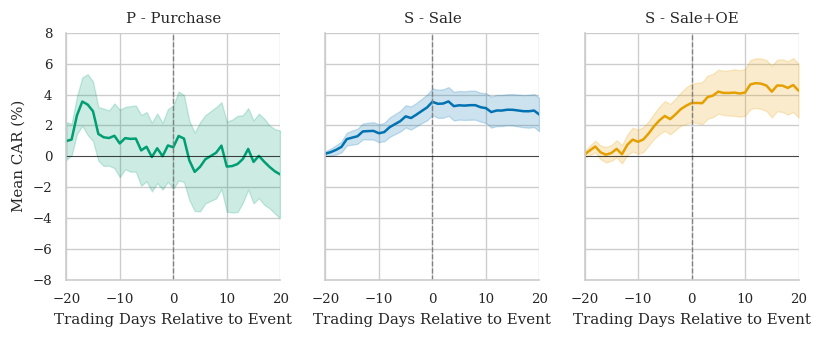

In [9]:
# fig 2: Average CAR Time Series (faceted by event type)
# merge ARs with metadata to get event_type
ar_typed = ar.merge(
    meta[["ticker", "event_date", "event_type"]],
    on=["ticker", "event_date"],
    how="left",
)

# compute relative day within each event window
ar_typed = ar_typed.sort_values(["ticker", "event_date", "event_type", "date"])
ar_typed["rel_day"] = ar_typed.groupby(["ticker", "event_date", "event_type"]).cumcount() - 20

# keep the event window only
ar_typed = ar_typed[ar_typed["rel_day"].between(-20, 20)].copy()

# cumulative AR -> CAR per event
ar_typed["CAR"] = ar_typed.groupby(["ticker", "event_date", "event_type"])["AR"].cumsum()

# cross-sectional mean +- SEM per event_type per relative day
ts = (
    ar_typed.groupby(["event_type", "rel_day"])["CAR"]
    .agg(["mean", "sem"])
    .reset_index()
)

# tighter symmetric y-limits based on plotted data
band = pd.concat([
    (ts["mean"] - ts["sem"]) * 100,
    (ts["mean"] + ts["sem"]) * 100,
])
y_lim = max(2, np.ceil(np.nanmax(np.abs(band)) / 2) * 2)

fig, axes = plt.subplots(1, len(EVENT_ORDER), figsize=(7, 3), sharey=True)

for ax, etype in zip(axes, EVENT_ORDER):
    sub = ts[ts["event_type"] == etype]

    ax.plot(
        sub["rel_day"],
        sub["mean"] * 100,
        color=EVENT_COLORS[etype],
        linewidth=1.5,
    )
    ax.fill_between(
        sub["rel_day"],
        (sub["mean"] - sub["sem"]) * 100,
        (sub["mean"] + sub["sem"]) * 100,
        alpha=0.2,
        color=EVENT_COLORS[etype],
    )

    ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
    ax.axhline(0, color="black", linewidth=0.4)
    ax.set_xlim(-20, 20)
    ax.set_ylim(-y_lim, y_lim)
    ax.set_title(etype, fontsize=9)
    ax.set_xlabel("Trading Days Relative to Event", fontsize=9)
    ax.tick_params(axis="both", labelsize=8)
    ax.yaxis.set_major_locator(mtick.MultipleLocator(2))

axes[0].set_ylabel("Mean CAR (%)", fontsize=9)
sns.despine()
fig.tight_layout()
fig.savefig(FIG / "fig2_car_timeseries_faceted.png")
plt.show()

For Purchases, the mean CAR drifts from around +2% at t=-20 down to roughly -1% by t=+20, but the wide confidence band (N=12) means this is indistinguishable from noise. Both Sale groups show a steady positive pre-event drift that begins well before t=0 and then flattens out after the filing date, with Sale+OE accumulating a larger drift (~+4%) than plain Sales (~+3%). The absence of any visible jump or kink at t=0 in either group suggests the market does not react sharply to the filing itself.

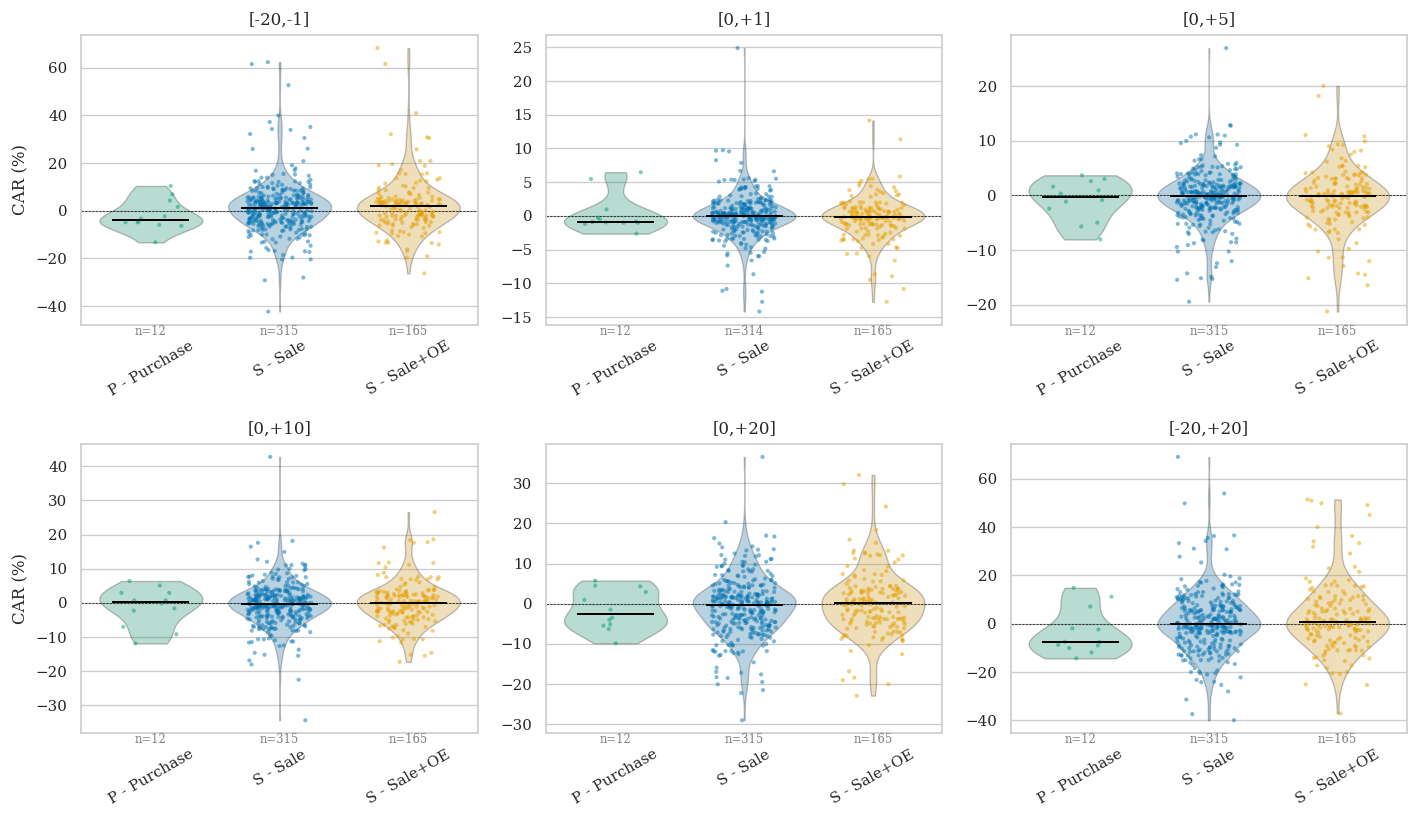

In [10]:
# fig 4b: CAR Distributions — Both Mode (violin + strip)
car_both = pd.read_csv(DATA / "cumulative_abnormal_returns_both.csv", parse_dates=["event_date"])
trad_both = car_both[car_both["source"] == "traditional"].copy()

both_long = trad_both.melt(
    id_vars=["ticker", "event_date", "event_type"],
    value_vars=CAR_WINDOWS,
    var_name="car_window",
    value_name="CAR",
)
both_long["CAR_pct"] = both_long["CAR"] * 100
both_long["car_label"] = both_long["car_window"].map(CAR_LABEL_MAP)

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey=False)
for idx, window in enumerate(CAR_WINDOWS):
    ax = axes.flat[idx]
    sub = both_long[both_long["car_window"] == window]

    sns.violinplot(
        data=sub, x="event_type", y="CAR_pct",
        order=EVENT_ORDER, palette=EVENT_COLORS,
        ax=ax, inner=None, linewidth=0.8, alpha=0.3, cut=0,
    )
    sns.stripplot(
        data=sub, x="event_type", y="CAR_pct",
        order=EVENT_ORDER, palette=EVENT_COLORS,
        ax=ax, size=2.5, alpha=0.5, jitter=0.25,
    )
    # median line per group
    for i, etype in enumerate(EVENT_ORDER):
        med = sub.loc[sub["event_type"] == etype, "CAR_pct"].median()
        ax.hlines(med, i - 0.3, i + 0.3, color="black", linewidth=1.2, zorder=5)

    ax.axhline(0, color="black", linewidth=0.4, linestyle="--")
    ax.set_title(CAR_LABEL_MAP[window], fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("CAR (%)" if idx % 3 == 0 else "")
    ax.tick_params(axis="x", rotation=30)

    # annotate N per group
    for i, etype in enumerate(EVENT_ORDER):
        n = sub.loc[sub["event_type"] == etype, "CAR_pct"].notna().sum()
        ax.text(i, ax.get_ylim()[0], f"n={n}", ha="center", va="top", fontsize=7, color="grey")

fig.tight_layout()
fig.savefig(FIG / "fig4b_car_distributions_both.png")
plt.show()

The CAR time series plots above show that average CARs remain close to zero across the entire event window for all three trade types, with wide standard-error bands especially for Purchases (reflecting N=12). There is no visible jump at t=0 for any group. The violin plots confirm that the CAR distributions are roughly symmetric around zero with a number of outliers in both tails, and the daily AR histograms are approximately normal with near-zero means. Overall the visual evidence is consistent with the statistical tests from notebook 04: no strong post-event abnormal returns.

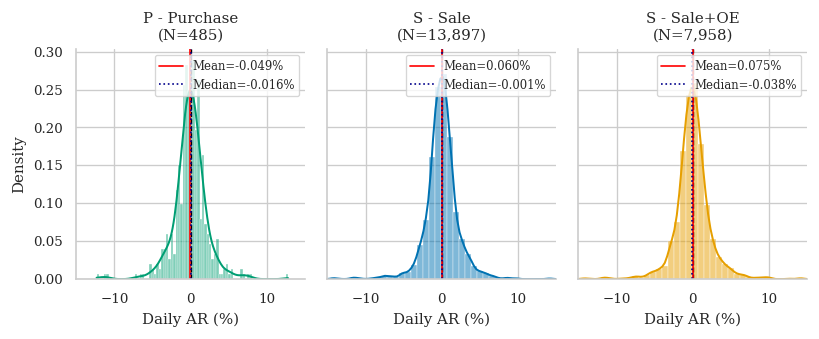

In [11]:
# fig 4c: Daily AR Distributions by Event Type
ar_typed = ar.merge(
    meta[["ticker", "event_date", "event_type"]],
    on=["ticker", "event_date"],
)
ar_typed["AR_pct"] = ar_typed["AR"] * 100

# compute relative day for labeling
ar_typed = ar_typed.sort_values(["ticker", "event_date", "event_type", "date"])
ar_typed["rel_day"] = ar_typed.groupby(["ticker", "event_date", "event_type"]).cumcount() - 20

# overall AR distribution by event type
fig, axes = plt.subplots(1, len(EVENT_ORDER), figsize=(7, 3), sharey=True)

for ax, etype in zip(axes, EVENT_ORDER):
    sub = ar_typed[ar_typed["event_type"] == etype]["AR_pct"]
    sns.histplot(sub, bins=80, kde=True, color=EVENT_COLORS[etype], edgecolor="white",
                 linewidth=0.2, ax=ax, stat="density")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.axvline(sub.mean(), color="red", linewidth=1, linestyle="-",
               label=f"Mean={sub.mean():.3f}%")
    ax.axvline(sub.median(), color="darkblue", linewidth=1, linestyle=":",
               label=f"Median={sub.median():.3f}%")
    ax.set_title(f"{etype}\n(N={len(sub):,})", fontsize=9)
    ax.set_xlabel("Daily AR (%)", fontsize=9)
    ax.tick_params(axis="both", labelsize=8)
    ax.legend(fontsize=7, loc="upper right")
    ax.set_xlim(-15, 15)

axes[0].set_ylabel("Density", fontsize=9)
sns.despine()
fig.tight_layout()
fig.savefig(FIG / "fig4c_ar_distributions.png")
plt.show()


## Section 3 — H3: LLM Validation

Here it is visualized whether the LLM-based approach produces significantly different CARs than the traditional market model. The heatmaps show p-values from the paired t-test and Wilcoxon signed-rank test, where cells with p < 0.05 are highlighted with a black border. If most cells are green (high p-values), the null hypothesis that the two methods give the same results cannot be rejected, which would validate the LLM approach.

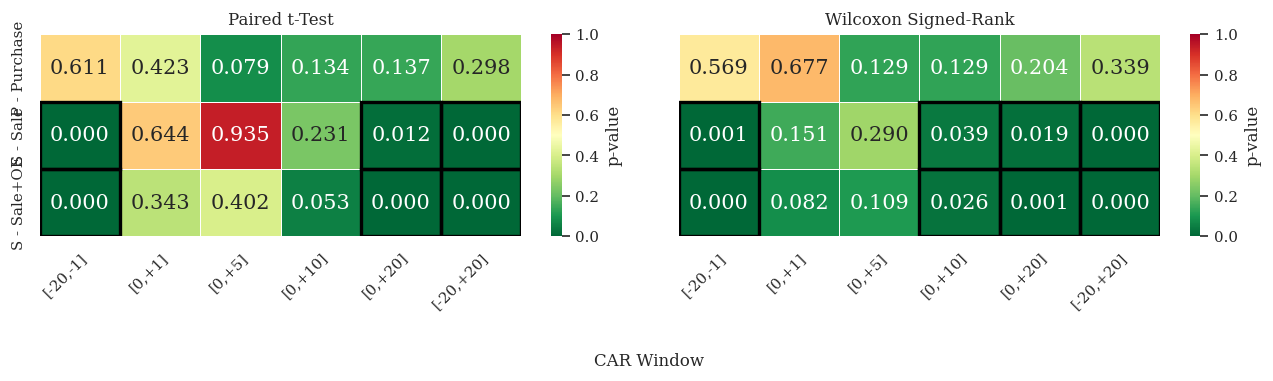

In [12]:
# fig 6: Comparison Test p-Values (dual heatmap)
comp = cs[cs["section"] == "comparison_test"].copy()
comp["event_type"] = comp["group"].str.extract(r"(P - Purchase|S - Sale\+OE|S - Sale)")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, test_name, title in zip(
    axes,
    ["paired_t_test", "wilcoxon_signed_rank"],
    ["Paired t-Test", "Wilcoxon Signed-Rank"],
):
    sub = comp[comp["test_type"] == test_name]
    pivot = sub.pivot(index="event_type", columns="car_window", values="p_value")
    pivot = pivot.reindex(index=EVENT_ORDER, columns=CAR_WINDOWS)
    pivot.columns = [CAR_LABEL_MAP[c] for c in pivot.columns]

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn_r",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        ax=ax,
        cbar_kws={"label": "p-value"},
    )

    # highlight significant cells (p < 0.05) with black rectangle
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            if pivot.iloc[i, j] < 0.05:
                ax.add_patch(Rectangle((j, i), 1, 1, fill=False, edgecolor="black", linewidth=2))

    ax.set_title(title, fontsize=10)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")

fig.supxlabel("CAR Window", fontsize=10)
fig.tight_layout()
fig.savefig(FIG / "fig6_comparison_heatmap.png")
plt.show()

## Section 4 — Significance Summary

The final set of figures summarizes the G-Rank test results as heatmaps. These show whether the mean (and median) CARs are significantly different from zero for each event type and CAR window. Again, cells with p < 0.05 get a black border. These heatmaps give a quick visual overview of where significant abnormal returns are found and where they are not.

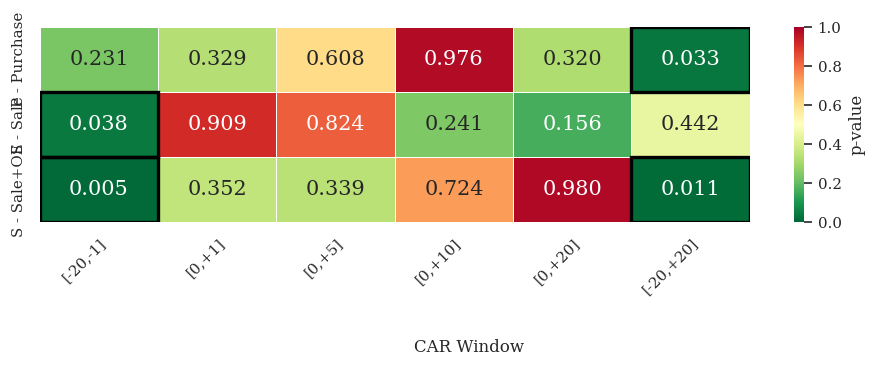

In [13]:
# fig 7: GRANK Test p-Values
grank_mean = cs[
    (cs["section"] == "grank_test")
    & (cs["test_type"] == "mean")
].copy()
grank_mean["event_type"] = grank_mean["group"].str.extract(r"(P - Purchase|S - Sale\+OE|S - Sale)")
grank_mean["is_trad"] = grank_mean["group"].str.contains("traditional")
grank_trad = grank_mean[grank_mean["is_trad"]]

pivot = grank_trad.pivot(index="event_type", columns="car_window", values="p_value")
pivot = pivot.reindex(index=EVENT_ORDER, columns=CAR_WINDOWS)
pivot.columns = [CAR_LABEL_MAP[c] for c in pivot.columns]

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "p-value"},
)

# highlight significant cells (p < 0.05) with black rectangle
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        if pivot.iloc[i, j] < 0.05:
            ax.add_patch(Rectangle((j, i), 1, 1, fill=False, edgecolor="black", linewidth=2))

ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45)
plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")
fig.supxlabel("CAR Window", fontsize=10)
fig.tight_layout()
fig.savefig(FIG / "fig7_grank_heatmap.png")
plt.show()

The G-Rank heatmaps above confirm the pattern from notebook 04. The only consistently significant CARs appear in the pre-event window CAR[-20,-1], particularly for Sale+OE transactions. Post-event windows are not statistically significant for any trade type, reinforcing that no detectable abnormal reaction to insider trade filings is observed in the days and weeks following the event. The median-based G-Rank test is even more conservative and finds no significance in any window for any group.

The LLM comparison heatmap shows that paired differences between traditional and LLM CARs are not significant for the short windows CAR[0,1] and CAR[0,5], but become significant for the pre-event and longer post-event windows. This indicates that the LLM-based market model is a reasonable approximation for short-horizon analyses, while the small systematic differences in estimated alpha and beta accumulate over wider windows.

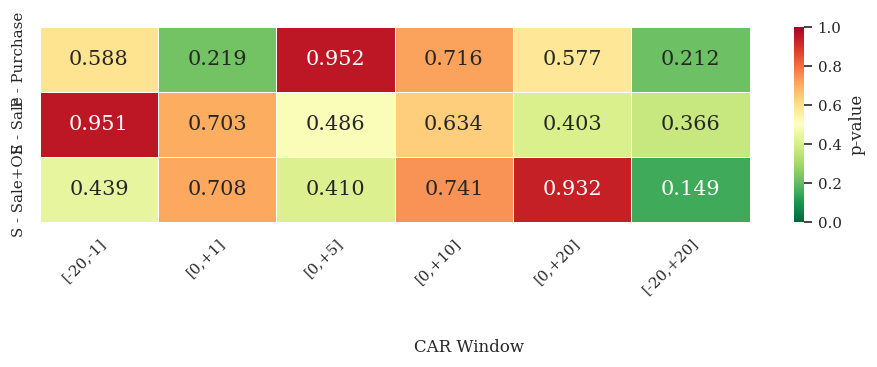

In [14]:
# fig 7b: GRANK Test p-Values - Median Test
grank_median = cs[
    (cs["section"] == "grank_test")
    & (cs["test_type"] == "median")
].copy()
grank_median["event_type"] = grank_median["group"].str.extract(r"(P - Purchase|S - Sale\+OE|S - Sale)")
grank_median["is_trad"] = grank_median["group"].str.contains("traditional")
grank_trad_med = grank_median[grank_median["is_trad"]]

pivot_med = grank_trad_med.pivot(index="event_type", columns="car_window", values="p_value")
pivot_med = pivot_med.reindex(index=EVENT_ORDER, columns=CAR_WINDOWS)
pivot_med.columns = [CAR_LABEL_MAP[c] for c in pivot_med.columns]

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(
    pivot_med,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "p-value"},
)

for i in range(pivot_med.shape[0]):
    for j in range(pivot_med.shape[1]):
        if pivot_med.iloc[i, j] < 0.05:
            ax.add_patch(Rectangle((j, i), 1, 1, fill=False, edgecolor="black", linewidth=2))

ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45)
plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")
fig.supxlabel("CAR Window", fontsize=10)
fig.tight_layout()
fig.savefig(FIG / "fig7b_grank_median_heatmap.png")
plt.show()